# **TFG - BUYING THROUGH AI AGENTS**
#### Clara Martin Peyrona & Alison-Rose Platt Portero


#### **LOAD AND PREPARE DATA**

In [11]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [12]:
# Load raw Excel file
FILE_PATH=('Data_vf_.xlsx')

In [13]:
df = pd.read_excel(FILE_PATH, sheet_name='RAW_DATA', header=1, skiprows=0)
df

,age,gender,country,education,profession,online_shop_freq,ai_familiarity,tech_comfort,ai_prior_use,PU1,...,AI1,AI2,AI3,CAT_clothing,CAT_cheap_electronics,CAT_expensive_electronics,CAT_flights,CAT_hotel,CAT_digital_services,open_answer
0,1,1,Spain,2,1,5,5,5,4,5,...,5,4,5,5,5,4,4,4,4,Protección real de datos y privacidad
1,1,2,Spain,2,7,3,5,5,5,5,...,5,4,5,1,4,4,4,4,4,"No confiaria mas, ya confio lo suficiente"
2,1,1,Spain,2,6,3,4,4,1,2,...,3,1,2,3,1,1,1,1,1,Es algo muy complicado porque creo que pueden ...
3,1,2,Spain,2,1,3,5,5,5,3,...,3,2,4,4,2,2,1,1,2,Confiaría más en agentes de compra con IA si c...
4,1,2,Spain,2,8,3,4,4,4,4,...,3,4,4,3,4,4,3,3,3,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2,1,Switzerland,2,2,2,3,4,4,3,...,3,4,3,2,2,3,3,3,3,100% confidentiality of all exchanged data. Ex...
196,2,2,Switzerland,4,6,2,5,4,5,3,...,2,3,5,4,4,4,5,2,4,I would need to believe that the company runni...
197,1,1,Spain,3,6,4,3,4,3,4,...,4,3,4,4,2,2,4,5,3,Para confiar más en los agentes de compra con ...
198,1,1,Spain,2,6,3,3,3,4,3,...,3,4,4,3,5,5,4,4,3,Que tuvieran toda la info sobre mi


### ***STEP 0: DESCRIPTIVE STATISTICS — SAMPLE PROFILE***

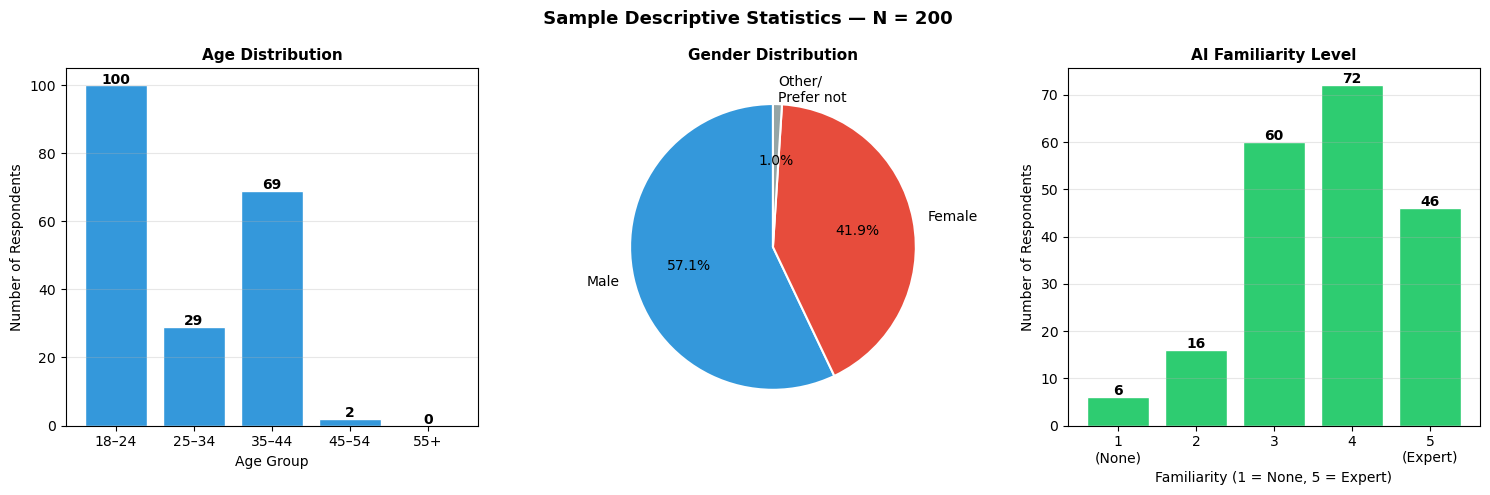

In [101]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(' Sample Descriptive Statistics — N = 200',
             fontsize=13, fontweight='bold')

# -- Plot 1: Age distribution --
age_map    = {1:'18–24', 2:'25–34', 3:'35–44', 4:'45–54', 5:'55+'}
age_order  = ['18–24','25–34','35–44','45–54','55+']
age_counts = df['age'].map(age_map).value_counts().reindex(age_order, fill_value=0)

bars_age = axes[0].bar(age_counts.index, age_counts.values,
                       color='#3498db', edgecolor='white')
for bar, val in zip(bars_age, age_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Age Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Age Group', fontsize=10)
axes[0].set_ylabel('Number of Respondents', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# -- Plot 2: Gender --
gender_map    = {1:'Male', 2:'Female', 3:'Other/\nPrefer not'}
gender_counts = df['gender'].map(gender_map).value_counts()
axes[1].pie(gender_counts.values,
            labels=gender_counts.index,
            autopct='%1.1f%%',
            colors=['#3498db','#e74c3c','#95a5a6'],
            startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Gender Distribution', fontsize=11, fontweight='bold')

# -- Plot 3: AI Familiarity --
fam_counts = df['ai_familiarity'].value_counts().sort_index()
fam_labels = {1:'1\n(None)', 2:'2', 3:'3', 4:'4', 5:'5\n(Expert)'}
bars_fam = axes[2].bar([fam_labels.get(i, str(i)) for i in fam_counts.index],
                        fam_counts.values,
                        color='#2ecc71', edgecolor='white')
for bar, val in zip(bars_fam, fam_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('AI Familiarity Level', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Familiarity (1 = None, 5 = Expert)', fontsize=10)
axes[2].set_ylabel('Number of Respondents', fontsize=10)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figure8_descriptive.png', dpi=150, bbox_inches='tight')
plt.show()


In [102]:
print()
print("=" * 65)
print("  END OF STEP 0 ")
print("=" * 65)


  END OF STEP 0 


### ***STEP 1: RELIABILITY ANALYSIS — CRONBACH'S ALPHA***

#### PURPOSE:
Before running any statistical model, we need to verify that the surveyitems measuring each variable are internally consistent, i.e., that people
who scored high on one item of a variable also scored high on the others. Cronbach's Alpha is the standard measure of this internal consistency.

#### INTERPRETATION:
Alpha >= 0.9  → Excellent
Alpha >= 0.8  → Good
Alpha >= 0.7  → Acceptable
Alpha <  0.7  → Questionable — needs attention

#### VARIABLES TESTED:
- Perceived Usefulness  (H1) → items PU1, PU2, PU3
- Trust                 (H2) → items TR1, TR2, TR3, TR4
- Perceived Risk        (H3) → items PR1, PR2, PR3, PR4
- Automation Preference (H4) → items AP1, AP2, AP3 (reverse coded)
- Adoption Intention    (DV) → items AI1, AI2, AI3

In [24]:
print("=" * 65)
print("  TFG — BUYING THROUGH AI AGENTS")
print("  STEP 1: RELIABILITY ANALYSIS — CRONBACH'S ALPHA")
print("=" * 65)
print(f"\n  Dataset loaded successfully")
print(f"  Total responses : {len(df)}")
print(f"  Total columns   : {df.shape[1]}")
 
likert_cols = [
    'PU1','PU2','PU3',
    'TR1','TR2','TR3','TR4',
    'PR1','PR2','PR3','PR4',
    'AP1','AP2','AP3',
    'AI1','AI2','AI3'
]
print(f"  Missing values in Likert items: {df[likert_cols].isnull().sum().sum()}")
print()

  TFG — BUYING THROUGH AI AGENTS
  STEP 1: RELIABILITY ANALYSIS — CRONBACH'S ALPHA

  Dataset loaded successfully
  Total responses : 200
  Total columns   : 33
  Missing values in Likert items: 0



#### **1.2. CRONBACH'S ALPHA FUNCTION**

**Formula:**
α = (k / (k-1)) × (1 - Σvar_i / var_total)

- k         = number of items
- Σvar_i    = sum of individual item variances
- var_total = variance of the total score (sum of all items)

 

In [25]:

def cronbach_alpha(df_items):
    df_items = df_items.dropna()
    k = df_items.shape[1]
    item_variances = df_items.var(axis=0, ddof=1)
    total_score = df_items.sum(axis=1)
    total_variance = total_score.var(ddof=1)
 
    alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)
 
    item_total_corr = pd.Series({
        col: df_items[col].corr(total_score - df_items[col])
        for col in df_items.columns
    })
 
    alpha_if_deleted = {}
    for col in df_items.columns:
        remaining = df_items.drop(columns=[col])
        k2 = remaining.shape[1]
        v2 = remaining.var(axis=0, ddof=1).sum()
        vt2 = remaining.sum(axis=1).var(ddof=1)
        alpha_if_deleted[col] = (k2 / (k2 - 1)) * (1 - v2 / vt2)
 
    return alpha, item_total_corr, pd.Series(alpha_if_deleted)


In [26]:
def interpret_alpha(alpha):
    if alpha >= 0.9:   return "Excellent"
    elif alpha >= 0.8: return "Good"
    elif alpha >= 0.7: return "Acceptable"
    elif alpha >= 0.6: return "Questionable"
    else:              return "Poor — review items"


#### **1.3. DEFINE VARIABLES AND THEIR ITEMS**

In [27]:
variables = {
    'Perceived Usefulness (H1)':  ['PU1', 'PU2', 'PU3'],
    'Trust (H2)':                 ['TR1', 'TR2', 'TR3', 'TR4'],
    'Perceived Risk (H3)':        ['PR1', 'PR2', 'PR3', 'PR4'],
    'Automation Preference (H4)': ['AP1', 'AP2', 'AP3'],
    'Adoption Intention (DV)':    ['AI1', 'AI2', 'AI3'],
}

#### **1.4. RUN ANALYSIS AND DISPLAY RESULTS**

In [28]:
results_summary = []
 
for var_name, items in variables.items():
 
    print("-" * 65)
    print(f"  VARIABLE: {var_name}")
    print(f"  Items   : {', '.join(items)}")
    print("-" * 65)
 
    alpha, item_total_corr, alpha_if_deleted = cronbach_alpha(df[items])
    interpretation = interpret_alpha(alpha)
 
    print(f"\n  Cronbach's Alpha: {alpha:.4f}  →  {interpretation}")
    print()
 
    detail = pd.DataFrame({
        'Item':             items,
        'Mean':             [round(df[i].mean(), 3) for i in items],
        'Std Dev':          [round(df[i].std(), 3)  for i in items],
        'Item-Total Corr':  [round(item_total_corr[i], 3)  for i in items],
        'Alpha if Deleted': [round(alpha_if_deleted[i], 3) for i in items],
    })
 
    print("  Item-level statistics:")
    print(detail.to_string(index=False))
    print()
 
    low_corr = [i for i in items if item_total_corr[i] < 0.3]
    if low_corr:
        print(f"  WARNING: {', '.join(low_corr)} have low item-total correlation (<0.3)")
 
    improve = {i: alpha_if_deleted[i] for i in items if alpha_if_deleted[i] > alpha + 0.05}
    if improve:
        for item, new_alpha in improve.items():
            print(f"  WARNING: Removing {item} would increase alpha to {new_alpha:.4f}")
 
    results_summary.append({
        'Variable':       var_name,
        'N Items':        len(items),
        'Cronbach Alpha': round(alpha, 4),
        'Interpretation': interpretation,
    })
    print()

-----------------------------------------------------------------
  VARIABLE: Perceived Usefulness (H1)
  Items   : PU1, PU2, PU3
-----------------------------------------------------------------

  Cronbach's Alpha: 0.8516  →  Good

  Item-level statistics:
Item  Mean  Std Dev  Item-Total Corr  Alpha if Deleted
 PU1 3.670    1.018            0.773             0.751
 PU2 3.625    1.118            0.692             0.821
 PU3 3.375    1.158            0.709             0.808


-----------------------------------------------------------------
  VARIABLE: Trust (H2)
  Items   : TR1, TR2, TR3, TR4
-----------------------------------------------------------------

  Cronbach's Alpha: 0.9092  →  Excellent

  Item-level statistics:
Item  Mean  Std Dev  Item-Total Corr  Alpha if Deleted
 TR1 3.265    1.150            0.762             0.894
 TR2 3.125    1.084            0.774             0.890
 TR3 3.185    1.089            0.817             0.875
 TR4 3.095    1.124            0.825         

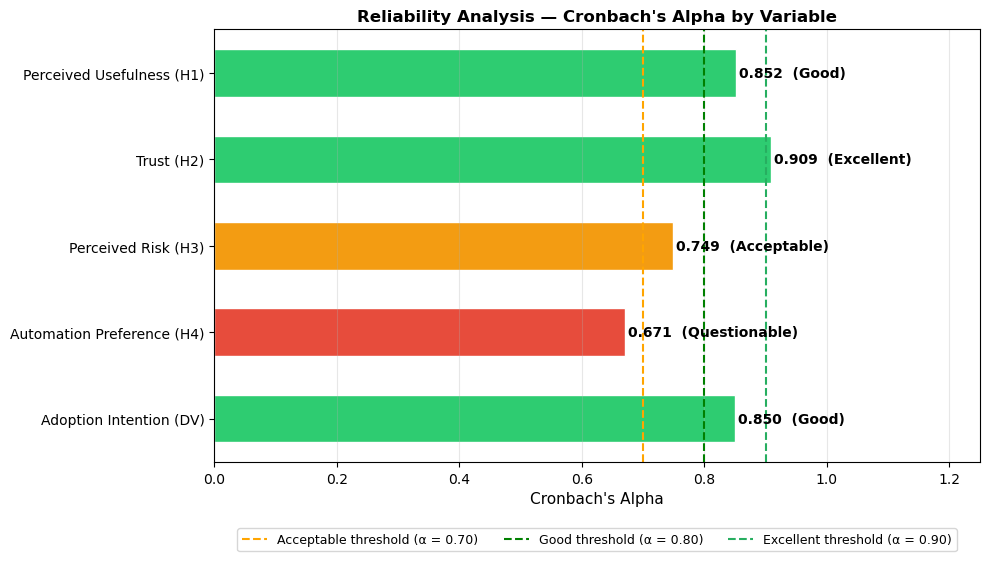

In [103]:
fig, ax = plt.subplots(figsize=(10, 6))  # más alto
alpha_vals   = [r['Cronbach Alpha'] for r in results_summary]
var_names    = [r['Variable']       for r in results_summary]
interps      = [r['Interpretation'] for r in results_summary]
colors_alpha = ['#2ecc71' if a >= 0.8 else '#f39c12' if a >= 0.7 else '#e74c3c' for a in alpha_vals]

bars = ax.barh(var_names, alpha_vals, color=colors_alpha, edgecolor='white', height=0.55)

ax.axvline(x=0.7, color='orange',  linestyle='--', linewidth=1.5, label='Acceptable threshold (α = 0.70)')
ax.axvline(x=0.8, color='green',   linestyle='--', linewidth=1.5, label='Good threshold (α = 0.80)')
ax.axvline(x=0.9, color='#27ae60', linestyle='--', linewidth=1.5, label='Excellent threshold (α = 0.90)')

for bar, val, interp in zip(bars, alpha_vals, interps):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}  ({interp})',
            va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, 1.25)
ax.set_xlabel("Cronbach's Alpha", fontsize=11)
ax.set_title("Reliability Analysis — Cronbach's Alpha by Variable", fontsize=12, fontweight='bold')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.22),
          ncol=3, fontsize=9, frameon=True)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig('figure1_cronbach.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
print("=" * 65)
print("  SUMMARY TABLE — CRONBACH'S ALPHA BY VARIABLE")
print("=" * 65)
print()
print(pd.DataFrame(results_summary).to_string(index=False))
print()
 
below = [r['Variable'] for r in results_summary if r['Cronbach Alpha'] < 0.70]
if not below:
    print("  All variables meet the minimum reliability threshold (a >= 0.70)")
    print("  The dataset is reliable and suitable for further analysis.")
else:
    print(f"  WARNING: The following variable(s) fall below a = 0.70: {', '.join(below)}")
    print("  This should be acknowledged in the Results and Discussion sections.")
 
print()
print("=" * 65)
print("  END OF STEP 1 ")
print("=" * 65)

  SUMMARY TABLE — CRONBACH'S ALPHA BY VARIABLE

                  Variable  N Items  Cronbach Alpha Interpretation
 Perceived Usefulness (H1)        3          0.8516           Good
                Trust (H2)        4          0.9092      Excellent
       Perceived Risk (H3)        4          0.7486     Acceptable
Automation Preference (H4)        3          0.6710   Questionable
   Adoption Intention (DV)        3          0.8502           Good

  This should be acknowledged in the Results and Discussion sections.

  END OF STEP 1 


### ***STEP 2: PEARSON CORRELATION ANALYSIS***

#### PURPOSE:
Examine bivariate relationships between all main variables using Pearson correlation coefficients. This step provides:
1. How each variable relates to Adoption Intention (DV)
2. A first indication of whether each hypothesis holds at the bivariate level
3. The direction of the H5 relationship (Trust <-> Perceived Risk)

#### INTERPRETATION OF PEARSON r:
r = 0.5 to 1.0  → Strong relationship
r = 0.3 to 0.5  → Moderate relationship
r = 0.1 to 0.3  → Weak relationship

Negative values → Inverse relationship

#### SIGNIFICANCE (p-value):
 p < 0.05  → Statistically significant
 p >= 0.05 → Not significant (could be due to chance)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
 

In [43]:
df = pd.read_excel(FILE_PATH, sheet_name='RAW_DATA', header=1)
df
 

,age,gender,country,education,profession,online_shop_freq,ai_familiarity,tech_comfort,ai_prior_use,PU1,...,AI1,AI2,AI3,CAT_clothing,CAT_cheap_electronics,CAT_expensive_electronics,CAT_flights,CAT_hotel,CAT_digital_services,open_answer
0,1,1,Spain,2,1,5,5,5,4,5,...,5,4,5,5,5,4,4,4,4,Protección real de datos y privacidad
1,1,2,Spain,2,7,3,5,5,5,5,...,5,4,5,1,4,4,4,4,4,"No confiaria mas, ya confio lo suficiente"
2,1,1,Spain,2,6,3,4,4,1,2,...,3,1,2,3,1,1,1,1,1,Es algo muy complicado porque creo que pueden ...
3,1,2,Spain,2,1,3,5,5,5,3,...,3,2,4,4,2,2,1,1,2,Confiaría más en agentes de compra con IA si c...
4,1,2,Spain,2,8,3,4,4,4,4,...,3,4,4,3,4,4,3,3,3,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2,1,Switzerland,2,2,2,3,4,4,3,...,3,4,3,2,2,3,3,3,3,100% confidentiality of all exchanged data. Ex...
196,2,2,Switzerland,4,6,2,5,4,5,3,...,2,3,5,4,4,4,5,2,4,I would need to believe that the company runni...
197,1,1,Spain,3,6,4,3,4,3,4,...,4,3,4,4,2,2,4,5,3,Para confiar más en los agentes de compra con ...
198,1,1,Spain,2,6,3,3,3,4,3,...,3,4,4,3,5,5,4,4,3,Que tuvieran toda la info sobre mi


In [44]:
# Calculate composite scores in the code (with clean variable names)
df['PERCEIVED_USEFULNESS']  = df[['PU1', 'PU2', 'PU3']].mean(axis=1)
df['TRUST']                 = df[['TR1', 'TR2', 'TR3', 'TR4']].mean(axis=1)
df['PERCEIVED_RISK']        = df[['PR1', 'PR2', 'PR3', 'PR4']].mean(axis=1)
df['AUTOMATION_PREFERENCE'] = df[['AP1', 'AP2', 'AP3']].mean(axis=1)
df['ADOPTION_INTENTION']    = df[['AI1', 'AI2', 'AI3']].mean(axis=1)
df['TRUST_x_RISK']          = df['TRUST'] * df['PERCEIVED_RISK']
 
print("=" * 70)
print("  TFG — BUYING THROUGH AI AGENTS")
print("  STEP 2: PEARSON CORRELATION ANALYSIS")
print("=" * 70)
print(f"\n  Dataset loaded: {len(df)} responses")
print()
 

  TFG — BUYING THROUGH AI AGENTS
  STEP 2: PEARSON CORRELATION ANALYSIS

  Dataset loaded: 200 responses



#### **2.1 DEFINE MAIN VARIABLES**

In [45]:
main_vars = [
    'PERCEIVED_USEFULNESS',
    'TRUST',
    'PERCEIVED_RISK',
    'AUTOMATION_PREFERENCE',
    'ADOPTION_INTENTION'
]
 
short_labels = {
    'PERCEIVED_USEFULNESS':  'Perceived\nUsefulness',
    'TRUST':                 'Trust',
    'PERCEIVED_RISK':        'Perceived\nRisk',
    'AUTOMATION_PREFERENCE': 'Automation\nPreference',
    'ADOPTION_INTENTION':    'Adoption\nIntention'
}

#### **2.2. PEARSON CORRELATION MATRIX (with p-values)**

In [46]:
def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''
 
 
print("-" * 70)
print("  CORRELATION MATRIX (Pearson r)")
print("  Significance: * p<0.05   ** p<0.01   *** p<0.001")
print("-" * 70)
print()
 
n = len(main_vars)
r_matrix = pd.DataFrame(np.ones((n, n)), index=main_vars, columns=main_vars)
p_matrix = pd.DataFrame(np.zeros((n, n)), index=main_vars, columns=main_vars)
 
for v1 in main_vars:
    for v2 in main_vars:
        r, p = stats.pearsonr(df[v1], df[v2])
        r_matrix.loc[v1, v2] = round(r, 3)
        p_matrix.loc[v1, v2] = p
 

----------------------------------------------------------------------
  CORRELATION MATRIX (Pearson r)
  Significance: * p<0.05   ** p<0.01   *** p<0.001
----------------------------------------------------------------------



In [47]:
# Print formatted matrix
header_line = "Variable".ljust(26)
for v in main_vars:
    header_line += f"{v[:8]:>14}"
print(header_line)
print("-" * len(header_line))
 
for v1 in main_vars:
    line = f"{v1:<26}"
    for v2 in main_vars:
        r = r_matrix.loc[v1, v2]
        p = p_matrix.loc[v1, v2]
        cell = f"{r:+.3f}{sig_stars(p)}"
        line += f"{cell:>14}"
    print(line)
print()

Variable                        PERCEIVE         TRUST      PERCEIVE      AUTOMATI      ADOPTION
------------------------------------------------------------------------------------------------
PERCEIVED_USEFULNESS           +1.000***     +0.770***        -0.103      -0.196**     +0.714***
TRUST                          +0.770***     +1.000***       -0.153*        -0.007     +0.686***
PERCEIVED_RISK                    -0.103       -0.153*     +1.000***     -0.444***       -0.146*
AUTOMATION_PREFERENCE           -0.196**        -0.007     -0.444***     +1.000***       -0.160*
ADOPTION_INTENTION             +0.714***     +0.686***       -0.146*       -0.160*     +1.000***



#### **2.3. CORRELATIONS WITH ADOPTION INTENTION (DV)**

In [48]:
print("-" * 70)
print("  CORRELATIONS WITH ADOPTION INTENTION (Dependent Variable)")
print("-" * 70)
print()
 
predictors = ['PERCEIVED_USEFULNESS', 'TRUST', 'PERCEIVED_RISK', 'AUTOMATION_PREFERENCE']
 
for var in predictors:
    r, p = stats.pearsonr(df[var], df['ADOPTION_INTENTION'])
    direction = "positive" if r > 0 else "negative"
    strength  = "strong" if abs(r) > 0.5 else "moderate" if abs(r) > 0.3 else "weak"
    print(f"  {var:<26} r = {r:+.3f}{sig_stars(p):<4} -> {strength} {direction}")
print()
 

----------------------------------------------------------------------
  CORRELATIONS WITH ADOPTION INTENTION (Dependent Variable)
----------------------------------------------------------------------

  PERCEIVED_USEFULNESS       r = +0.714***  -> strong positive
  TRUST                      r = +0.686***  -> strong positive
  PERCEIVED_RISK             r = -0.146*    -> weak negative
  AUTOMATION_PREFERENCE      r = -0.160*    -> weak negative



#### **2.4. H5 — TRUST x PERCEIVED RISK**


In [49]:
print("-" * 70)
print("  H5: Trust moderates the effect of Perceived Risk")
print("-" * 70)
print()
 
r_tr_pr, p_tr_pr = stats.pearsonr(df['TRUST'], df['PERCEIVED_RISK'])
r_tr_ai, p_tr_ai = stats.pearsonr(df['TRUST'], df['ADOPTION_INTENTION'])
r_pr_ai, p_pr_ai = stats.pearsonr(df['PERCEIVED_RISK'], df['ADOPTION_INTENTION'])
 
print(f"  Trust   <-> Perceived Risk      : r = {r_tr_pr:+.3f}  {sig_stars(p_tr_pr)}")
print(f"  Trust   <-> Adoption Intention  : r = {r_tr_ai:+.3f}  {sig_stars(p_tr_ai)}")
print(f"  Risk    <-> Adoption Intention  : r = {r_pr_ai:+.3f}  {sig_stars(p_pr_ai)}")
print()
if r_tr_pr < 0:
    print("  Interpretation: Trust and Perceived Risk are inversely related.")
    print("  This is consistent with H5 — full moderation tested in Step 3.")
print()

----------------------------------------------------------------------
  H5: Trust moderates the effect of Perceived Risk
----------------------------------------------------------------------

  Trust   <-> Perceived Risk      : r = -0.153  *
  Trust   <-> Adoption Intention  : r = +0.686  ***
  Risk    <-> Adoption Intention  : r = -0.146  *

  Interpretation: Trust and Perceived Risk are inversely related.
  This is consistent with H5 — full moderation tested in Step 3.



#### **2.5. VISUALISATION**

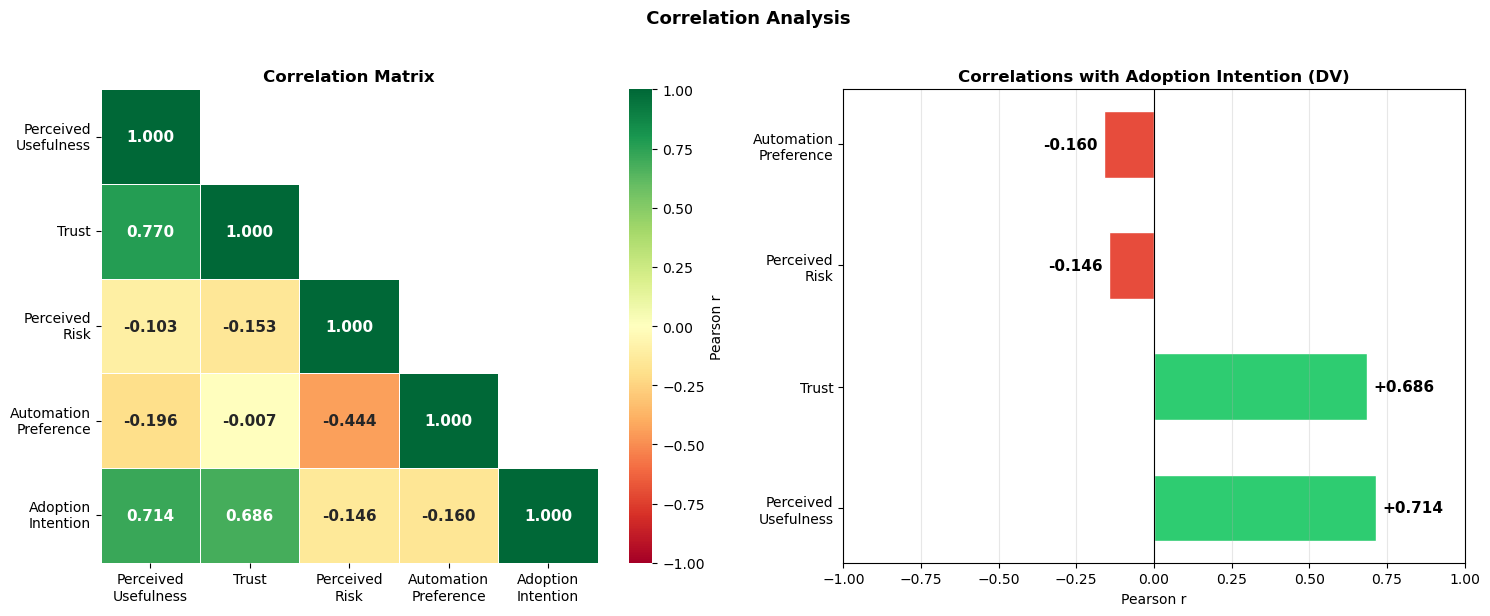

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(' Correlation Analysis',
             fontsize=13, fontweight='bold', y=1.02)
 
# --- Plot 1: Heatmap (lower triangle only) ---
ax1 = axes[0]
labels_list = [short_labels[v] for v in main_vars]
mask = np.triu(np.ones_like(r_matrix, dtype=bool), k=1)
 
sns.heatmap(
    r_matrix,
    ax=ax1,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    mask=mask,
    xticklabels=labels_list,
    yticklabels=labels_list,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'},
    cbar_kws={'label': 'Pearson r'}
)
ax1.set_title('Correlation Matrix', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=0)
ax1.tick_params(axis='y', rotation=0)
 
# --- Plot 2: Bar chart correlations with Adoption Intention ---
ax2 = axes[1]
corr_vals = [r_matrix.loc[v, 'ADOPTION_INTENTION'] for v in predictors]
corr_lbls = [short_labels[v] for v in predictors]
colors    = ['#2ecc71' if r > 0 else '#e74c3c' for r in corr_vals]
 
bars = ax2.barh(corr_lbls, corr_vals, color=colors, edgecolor='white', height=0.55)
 
for bar, val in zip(bars, corr_vals):
    ax2.text(
        val + (0.02 if val >= 0 else -0.02),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=11, fontweight='bold'
    )
 
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_xlim(-1, 1)
ax2.set_xlabel('Pearson r', fontsize=10)
ax2.set_title('Correlations with Adoption Intention (DV)', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
 
plt.tight_layout()

plt.show()


#### **2.6 SUMMARY OF HYPOTHESES (at correlation level)**

In [55]:
print("=" * 70)
print("  SUMMARY — HYPOTHESES AT CORRELATION LEVEL")
print("=" * 70)
print()
 
hypotheses = [
    ("H1 (Perceived Usefulness  -> Adoption, expected +)", 'PERCEIVED_USEFULNESS', 'positive'),
    ("H2 (Trust                 -> Adoption, expected +)", 'TRUST',                'positive'),
    ("H3 (Perceived Risk        -> Adoption, expected -)", 'PERCEIVED_RISK',       'negative'),
    ("H4 (Automation Preference -> Adoption, expected +)", 'AUTOMATION_PREFERENCE','positive'),
]
 
for label, var, expected in hypotheses:
    r, p = stats.pearsonr(df[var], df['ADOPTION_INTENTION'])
    supported = (expected == 'positive' and r > 0 and p < 0.05) or \
                (expected == 'negative' and r < 0 and p < 0.05)
    result = "SUPPORTED" if supported else "NOT SUPPORTED"
    print(f"  {label}")
    print(f"     r = {r:+.3f} {sig_stars(p)}  ->  {result}")
    print()
 
print("  H5 (Trust moderates Perceived Risk):")
print(f"     Trust <-> Risk: r = {r_tr_pr:+.3f} {sig_stars(p_tr_pr)}")
print(f"     Full moderation test in Step 3 (MLR with interaction term)")
print()
print("  NOTE: Pearson correlation only shows direction and strength.")
print("  The MLR in Step 3 will control for all variables simultaneously.")
print()
print("=" * 70)
print("  END OF STEP 2")
print("=" * 70)

  SUMMARY — HYPOTHESES AT CORRELATION LEVEL

  H1 (Perceived Usefulness  -> Adoption, expected +)
     r = +0.714 ***  ->  SUPPORTED

  H2 (Trust                 -> Adoption, expected +)
     r = +0.686 ***  ->  SUPPORTED

  H3 (Perceived Risk        -> Adoption, expected -)
     r = -0.146 *  ->  SUPPORTED

  H4 (Automation Preference -> Adoption, expected +)
     r = -0.160 *  ->  NOT SUPPORTED

  H5 (Trust moderates Perceived Risk):
     Trust <-> Risk: r = -0.153 *
     Full moderation test in Step 3 (MLR with interaction term)

  NOTE: Pearson correlation only shows direction and strength.
  The MLR in Step 3 will control for all variables simultaneously.

  END OF STEP 2


### **STEP 3: MULTIPLE LINEAR REGRESSION (MLR)**

#### PURPOSE:
This is the main analytical step of the study. It tests all five hypotheses (H1 to H5) by simultaneously evaluating the effect of each independent variable on Adoption Intention while controlling for the others.

#### HYPOTHESES TESTED:
H1: Perceived Usefulness  -> Adoption (expected POSITIVE)
H2: Trust                 -> Adoption (expected POSITIVE)
H3: Perceived Risk        -> Adoption (expected NEGATIVE)
H4: Automation Preference -> Adoption (expected POSITIVE)
H5: Trust × Perceived Risk -> Adoption (interaction term — moderation)

#### OUTPUT METRICS:
- Beta coefficient (β): direction and size of the effect
- Standard Error: precision of the estimate
- t-statistic and p-value: statistical significance
- R²: % of variance in Adoption Intention explained by the model
- Adjusted R²: R² adjusted for the number of predictors
- F-statistic: overall significance of the model
- VIF: multicollinearity check (should be < 5)

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
 

#### **3.1 PREPARE VARIABLES**

Predictors (independent variables) — including TRUST_x_RISK for H5

**IMPORTANT:** For interaction terms, we follow the standard practice of MEAN-CENTERING the variables before multiplying them. This avoids multicollinearity issues between TRUST, PERCEIVED_RISK and TRUST_x_RISK.Mean-centering does not change the interaction effect — only the main effects are easier to interpret.

In [57]:
predictors = [
    'PERCEIVED_USEFULNESS',
    'TRUST',
    'PERCEIVED_RISK',
    'AUTOMATION_PREFERENCE',
    'TRUST_x_RISK'
]
 
# Dependent variable
target = 'ADOPTION_INTENTION'
 
# Build X with mean-centered TRUST and PERCEIVED_RISK and a properly
# computed interaction term
X = df[predictors[:-1]].copy()  # take all except TRUST_x_RISK
 
trust_centered = X['TRUST'] - X['TRUST'].mean()
risk_centered  = X['PERCEIVED_RISK'] - X['PERCEIVED_RISK'].mean()
 
X['TRUST_x_RISK'] = trust_centered * risk_centered  # interaction (centered)
 
y = df[target].copy()
 
print(f"  Predictors  : {len(predictors)}")
print(f"  Sample size : {len(y)}")
print(f"  DV          : {target}")
print(f"  Note        : TRUST and PERCEIVED_RISK mean-centered before interaction")
print()
 
 

  Predictors  : 5
  Sample size : 200
  DV          : ADOPTION_INTENTION
  Note        : TRUST and PERCEIVED_RISK mean-centered before interaction



#### **3.2  FIT THE LINEAR REGRESSION MODEL**

In [58]:
# We use scikit-learn's LinearRegression to fit the model:
#   ADOPTION = β0 + β1*PU + β2*TRUST + β3*RISK + β4*AP + β5*(TRUST*RISK) + ε
 
model = LinearRegression()
model.fit(X, y)
 
# Predicted values and residuals
y_pred = model.predict(X)
residuals = y - y_pred
 
# Coefficients
intercept = model.intercept_
coefficients = model.coef_
 
# R² and Adjusted R²
n = len(y)
k = X.shape[1]
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared = 1 - (ss_res / ss_tot)
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)
 
# F-statistic
f_stat = (r_squared / k) / ((1 - r_squared) / (n - k - 1))
f_pvalue = 1 - stats.f.cdf(f_stat, k, n - k - 1)
 
# Standard errors of the coefficients
mse = ss_res / (n - k - 1)
X_with_intercept = np.hstack([np.ones((n, 1)), X.values])
cov_matrix = mse * np.linalg.inv(X_with_intercept.T @ X_with_intercept)
std_errors = np.sqrt(np.diag(cov_matrix))
 
# t-statistics and p-values
all_coefs = np.concatenate([[intercept], coefficients])
t_stats = all_coefs / std_errors
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - k - 1))

#### **3.3 PRINT MODEL SUMMARY**

In [59]:
def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''
 
print("-" * 75)
print("  MODEL FIT")
print("-" * 75)
print(f"  R-squared            : {r_squared:.4f}")
print(f"  Adjusted R-squared   : {adj_r_squared:.4f}")
print(f"  F-statistic          : {f_stat:.4f}")
print(f"  Prob (F-statistic)   : {f_pvalue:.6f}  {sig_stars(f_pvalue)}")
print(f"  Number of obs        : {n}")
print(f"  Number of predictors : {k}")
print(f"  Residual std error   : {np.sqrt(mse):.4f}")
print()
 
# Interpretation of R²
print(f"  >> The model explains {r_squared*100:.1f}% of the variance in Adoption Intention.")
print()

---------------------------------------------------------------------------
  MODEL FIT
---------------------------------------------------------------------------
  R-squared            : 0.5714
  Adjusted R-squared   : 0.5604
  F-statistic          : 51.7329
  Prob (F-statistic)   : 0.000000  ***
  Number of obs        : 200
  Number of predictors : 5
  Residual std error   : 0.6747

  >> The model explains 57.1% of the variance in Adoption Intention.



#### **3.4.COEFFICIENT TABLE**

In [60]:
print("-" * 75)
print("  REGRESSION COEFFICIENTS")
print("  Significance: * p<0.05   ** p<0.01   *** p<0.001")
print("-" * 75)
print()
 
var_names = ['(Intercept)'] + predictors
 
coef_table = pd.DataFrame({
    'Variable':   var_names,
    'Coef (β)':   [round(c, 4) for c in all_coefs],
    'Std Error':  [round(s, 4) for s in std_errors],
    't-stat':     [round(t, 3) for t in t_stats],
    'p-value':    [round(p, 4) for p in p_values],
    'Sig.':       [sig_stars(p) for p in p_values]
})
 
print(coef_table.to_string(index=False))
print()

---------------------------------------------------------------------------
  REGRESSION COEFFICIENTS
  Significance: * p<0.05   ** p<0.01   *** p<0.001
---------------------------------------------------------------------------

             Variable  Coef (β)  Std Error  t-stat  p-value Sig.
          (Intercept)    1.5193     0.4041   3.760   0.0002  ***
 PERCEIVED_USEFULNESS    0.4146     0.0824   5.030   0.0000  ***
                TRUST    0.3762     0.0783   4.805   0.0000  ***
       PERCEIVED_RISK   -0.1170     0.0640  -1.828   0.0691     
AUTOMATION_PREFERENCE   -0.1589     0.0699  -2.273   0.0241    *
         TRUST_x_RISK    0.0551     0.0500   1.101   0.2722     



#### **3.5. STANDARDISED COEFFICIENTS (BETA)**

Standardised coefficients allow us to compare the relative importance of each predictor on the same scale (-1 to +1 range), which is more
meaningful when variables are on different scales.
 

In [61]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_std = scaler_X.fit_transform(X)
y_std = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()
 
model_std = LinearRegression()
model_std.fit(X_std, y_std)
 
print("-" * 75)
print("  STANDARDISED COEFFICIENTS (Beta) — for comparing relative importance")
print("-" * 75)
print()
std_table = pd.DataFrame({
    'Variable':       predictors,
    'Std. Beta':      [round(b, 4) for b in model_std.coef_],
    'Abs. Importance':[round(abs(b), 4) for b in model_std.coef_]
}).sort_values('Abs. Importance', ascending=False)
 
print(std_table.to_string(index=False))
print()
 
 

---------------------------------------------------------------------------
  STANDARDISED COEFFICIENTS (Beta) — for comparing relative importance
---------------------------------------------------------------------------

             Variable  Std. Beta  Abs. Importance
 PERCEIVED_USEFULNESS     0.3934           0.3934
                TRUST     0.3645           0.3645
AUTOMATION_PREFERENCE    -0.1264           0.1264
       PERCEIVED_RISK    -0.0987           0.0987
         TRUST_x_RISK     0.0524           0.0524



#### **3.6. MULTICOLLINEARITY CHECK (VIF)**

VIF (Variance Inflation Factor) detects whether predictors are too correlated with each other. A VIF above 5 indicates a problem.

In [62]:
print("-" * 75)
print("  MULTICOLLINEARITY CHECK (VIF)")
print("  VIF < 5: OK   |   VIF >= 5: potential multicollinearity issue")
print("-" * 75)
print()
 
vif_data = []
for i, col in enumerate(predictors):
    other_cols = [c for c in predictors if c != col]
    aux_model = LinearRegression()
    aux_model.fit(X[other_cols], X[col])
    r2_aux = aux_model.score(X[other_cols], X[col])
    vif = 1 / (1 - r2_aux) if r2_aux < 1 else float('inf')
    vif_data.append({'Variable': col, 'VIF': round(vif, 3)})
 
vif_df = pd.DataFrame(vif_data)
print(vif_df.to_string(index=False))
print()

---------------------------------------------------------------------------
  MULTICOLLINEARITY CHECK (VIF)
  VIF < 5: OK   |   VIF >= 5: potential multicollinearity issue
---------------------------------------------------------------------------

             Variable   VIF
 PERCEIVED_USEFULNESS 2.769
                TRUST 2.604
       PERCEIVED_RISK 1.321
AUTOMATION_PREFERENCE 1.400
         TRUST_x_RISK 1.026



#### **3.7 HYPOTHESIS TESTING SUMMARY**

In [63]:
print("=" * 75)
print("  HYPOTHESIS TESTING — FINAL RESULTS")
print("=" * 75)
print()
 
hyp_results = [
    ("H1", "Perceived Usefulness  -> Adoption (positive)",  'PERCEIVED_USEFULNESS', '+'),
    ("H2", "Trust                 -> Adoption (positive)",  'TRUST',                '+'),
    ("H3", "Perceived Risk        -> Adoption (negative)",  'PERCEIVED_RISK',       '-'),
    ("H4", "Automation Preference -> Adoption (positive)",  'AUTOMATION_PREFERENCE','+'),
    ("H5", "Trust × Risk          -> Adoption (moderation)",'TRUST_x_RISK',          '?'),
]
 
for hyp_id, hyp_text, var, expected in hyp_results:
    idx = predictors.index(var) + 1  # +1 because intercept is first
    coef = all_coefs[idx]
    pval = p_values[idx]
 
    if expected == '+':
        supported = (coef > 0 and pval < 0.05)
    elif expected == '-':
        supported = (coef < 0 and pval < 0.05)
    else:
        supported = (pval < 0.05)
 
    result = "SUPPORTED" if supported else "NOT SUPPORTED"
    print(f"  {hyp_id}: {hyp_text}")
    print(f"      β = {coef:+.4f}, p = {pval:.4f} {sig_stars(pval)}  ->  {result}")
    print()

  HYPOTHESIS TESTING — FINAL RESULTS

  H1: Perceived Usefulness  -> Adoption (positive)
      β = +0.4146, p = 0.0000 ***  ->  SUPPORTED

  H2: Trust                 -> Adoption (positive)
      β = +0.3762, p = 0.0000 ***  ->  SUPPORTED

  H3: Perceived Risk        -> Adoption (negative)
      β = -0.1170, p = 0.0691   ->  NOT SUPPORTED

  H4: Automation Preference -> Adoption (positive)
      β = -0.1589, p = 0.0241 *  ->  NOT SUPPORTED

  H5: Trust × Risk          -> Adoption (moderation)
      β = +0.0551, p = 0.2722   ->  NOT SUPPORTED



#### **3.8. VISUALISATION**

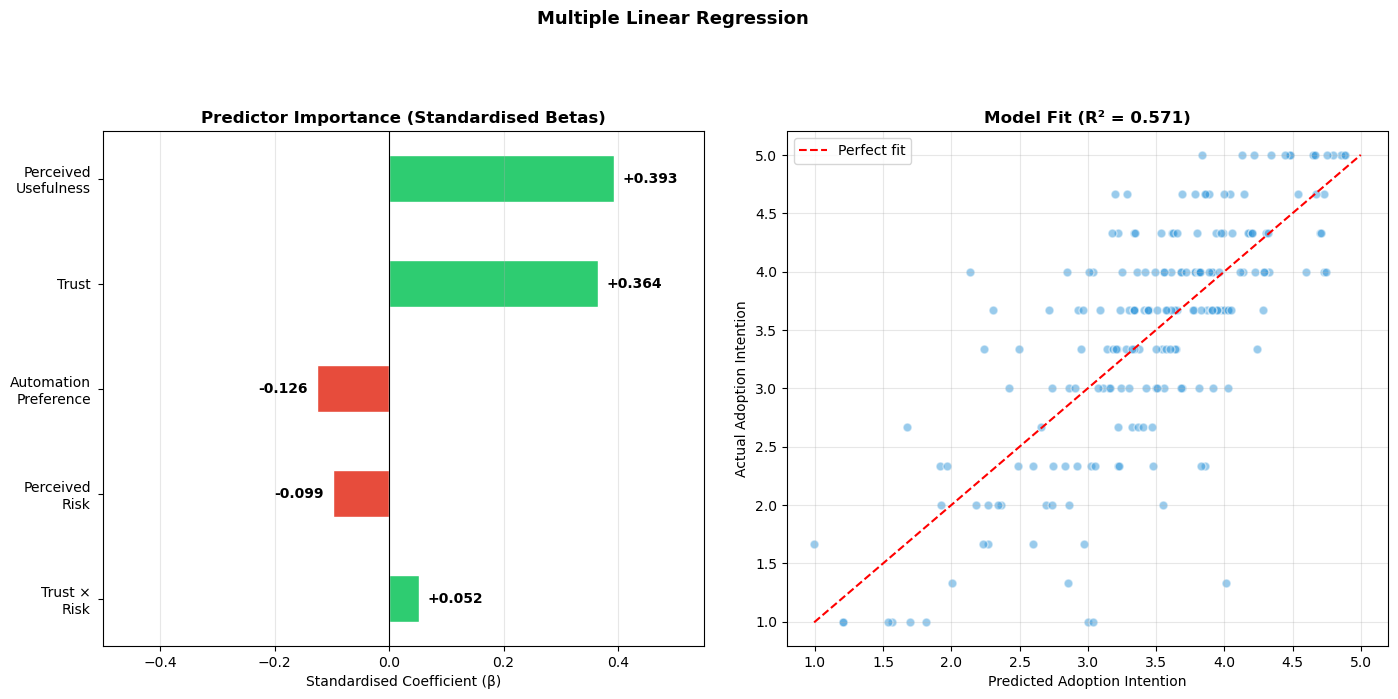

  END OF STEP 3 


In [105]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))  # más alto
fig.suptitle('Multiple Linear Regression',
             fontsize=13, fontweight='bold', y=1.02)

# --- Plot 1: Standardised coefficients bar chart ---
ax1 = axes[0]
std_betas = list(model_std.coef_)
labels = ['Perceived\nUsefulness', 'Trust', 'Perceived\nRisk',
          'Automation\nPreference', 'Trust ×\nRisk']

# Sort by absolute importance
order = np.argsort([abs(b) for b in std_betas])[::-1]
sorted_betas  = [std_betas[i] for i in order]
sorted_labels = [labels[i] for i in order]
colors = ['#2ecc71' if b > 0 else '#e74c3c' for b in sorted_betas]

bars = ax1.barh(sorted_labels, sorted_betas, color=colors, 
                edgecolor='white', height=0.45)  # barras más finas

for bar, val in zip(bars, sorted_betas):
    ax1.text(
        val + (0.015 if val >= 0 else -0.015),
        bar.get_y() + bar.get_height()/2,
        f'{val:+.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=10, fontweight='bold'
    )

ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_xlim(-0.5, 0.55)  # ampliar eje X
ax1.set_xlabel('Standardised Coefficient (β)', fontsize=10)
ax1.set_title('Predictor Importance (Standardised Betas)',
              fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelsize=10, pad=5)  # separar etiquetas
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# --- Plot 2: Predicted vs Actual scatter ---
ax2 = axes[1]
ax2.scatter(y_pred, y, alpha=0.5, s=40, color='#3498db', edgecolor='white')

# Perfect fit line
mn, mx = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
ax2.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')

ax2.set_xlabel('Predicted Adoption Intention', fontsize=10)
ax2.set_ylabel('Actual Adoption Intention', fontsize=10)
ax2.set_title(f'Model Fit (R² = {r_squared:.3f})',
              fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout(pad=2.5)
plt.subplots_adjust(left=0.12)
plt.savefig('step3_regression_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 75)
print("  END OF STEP 3 ")
print("=" * 75)

### ***STEP 4: RANDOM FOREST REGRESSION***

#### PURPOSE:
Random Forest is a machine learning algorithm that complements the MLRStep 3) by:
1. Capturing non-linear relationships and interactions between variables
2. Providing a robustness check on which variables matter most
3. Confirming or challenging the conclusions from the linear regression

It works by building hundreds of decision trees, each trained on a random subset of data, and combining their predictions. The "feature importance" measure tells us which variables contributed most to the
prediction across all trees.

#### OUTPUT METRICS:
- R² (training and test): how well the model predicts
- Feature importance: ranking of each predictor's contribution
- Comparison with MLR results

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

#### **4.1. PREPARE VARIABLES**

We use the same predictors as the MLR (without the interaction term — Random Forest detects interactions automatically).

In [70]:
predictors = [
    'PERCEIVED_USEFULNESS',
    'TRUST',
    'PERCEIVED_RISK',
    'AUTOMATION_PREFERENCE'
]
target = 'ADOPTION_INTENTION'
 
X = df[predictors].copy()
y = df[target].copy()
 
print(f"  Predictors  : {len(predictors)}")
print(f"  Sample size : {len(y)}")
print(f"  DV          : {target}")
print(f"  Note        : Random Forest detects interactions automatically,")
print(f"                so the TRUST_x_RISK term is not needed here.")
print()
 

  Predictors  : 4
  Sample size : 200
  DV          : ADOPTION_INTENTION
  Note        : Random Forest detects interactions automatically,
                so the TRUST_x_RISK term is not needed here.



#### **4.2. TRAIN-TEST SPLIT**

We split the data into training (80%) and testing (20%) sets. This allows us to evaluate the model on data it hasn't seen during training.
 

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print(f"  Training set: {len(X_train)} responses")
print(f"  Test set    : {len(X_test)} responses")
print()

  Training set: 160 responses
  Test set    : 40 responses



#### **4.3. FIT THE RANDOM FOREST MODEL**

We use 500 trees with default settings — robust and standard for this type of analysis.

In [72]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
 
rf_model.fit(X_train, y_train)
 
# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)

#### **4.4 MODEL PERFORMANCE**

In [73]:
print("-" * 75)
print("  MODEL PERFORMANCE")
print("-" * 75)
print()
 
train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
 
# Cross-validation R²
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
 
print(f"  Training R²        : {train_r2:.4f}")
print(f"  Test R²            : {test_r2:.4f}")
print(f"  Cross-val R² (mean): {cv_scores.mean():.4f}  (std: {cv_scores.std():.4f})")
print(f"  Test MAE           : {test_mae:.4f}")
print(f"  Test RMSE          : {test_rmse:.4f}")
print()
print(f"  >> The model explains {test_r2*100:.1f}% of the variance in unseen data.")
print()
 
 

---------------------------------------------------------------------------
  MODEL PERFORMANCE
---------------------------------------------------------------------------

  Training R²        : 0.8534
  Test R²            : 0.1735
  Cross-val R² (mean): 0.4889  (std: 0.0674)
  Test MAE           : 0.6187
  Test RMSE          : 0.8782

  >> The model explains 17.4% of the variance in unseen data.



#### **4.5. FEATURE IMPORTANCE**

Random Forest tells us which variables contributed the most to the prediction. The values sum to 1.0 (i.e. 100% of the importance).

In [74]:
print("-" * 75)
print("  FEATURE IMPORTANCE — Which variables drive Adoption Intention?")
print("-" * 75)
print()
 
importance_df = pd.DataFrame({
    'Variable':           predictors,
    'Importance':         rf_model.feature_importances_,
    'Importance (%)':     [f"{imp*100:.1f}%" for imp in rf_model.feature_importances_]
}).sort_values('Importance', ascending=False).reset_index(drop=True)
 
importance_df['Rank'] = range(1, len(importance_df) + 1)
importance_df = importance_df[['Rank', 'Variable', 'Importance', 'Importance (%)']]
 
print(importance_df.to_string(index=False))
print()

---------------------------------------------------------------------------
  FEATURE IMPORTANCE — Which variables drive Adoption Intention?
---------------------------------------------------------------------------

 Rank              Variable  Importance Importance (%)
    1  PERCEIVED_USEFULNESS    0.524531          52.5%
    2                 TRUST    0.313397          31.3%
    3        PERCEIVED_RISK    0.100638          10.1%
    4 AUTOMATION_PREFERENCE    0.061434           6.1%



#### **4.6. COMPARISON WITH MLR (STEP 3)**

In [75]:
print("-" * 75)
print("  COMPARISON WITH STEP 3 (Multiple Linear Regression)")
print("-" * 75)
print()
 
# These are the standardised betas from the MLR (Step 3 results)
mlr_results = {
    'PERCEIVED_USEFULNESS':  0.3934,
    'TRUST':                 0.3645,
    'PERCEIVED_RISK':       -0.0987,
    'AUTOMATION_PREFERENCE':-0.1264
}
 
comparison = pd.DataFrame({
    'Variable':             predictors,
    'MLR (std. β)':         [round(mlr_results[v], 3) for v in predictors],
    'MLR Rank':             [sorted(predictors, key=lambda x: -abs(mlr_results[x])).index(v) + 1 for v in predictors],
    'Random Forest (imp.)': [round(rf_model.feature_importances_[i], 3) for i in range(len(predictors))],
    'RF Rank':              [list(importance_df['Variable']).index(v) + 1 for v in predictors]
})
 
print(comparison.to_string(index=False))
print()
 
print("  Interpretation:")
print("  - If both methods rank variables similarly, the findings are robust.")
print("  - If they differ, the differences may indicate non-linear effects")
print("    that the linear regression couldn't capture.")
print()
 
 

---------------------------------------------------------------------------
  COMPARISON WITH STEP 3 (Multiple Linear Regression)
---------------------------------------------------------------------------

             Variable  MLR (std. β)  MLR Rank  Random Forest (imp.)  RF Rank
 PERCEIVED_USEFULNESS         0.393         1                 0.525        1
                TRUST         0.364         2                 0.313        2
       PERCEIVED_RISK        -0.099         4                 0.101        3
AUTOMATION_PREFERENCE        -0.126         3                 0.061        4

  Interpretation:
  - If both methods rank variables similarly, the findings are robust.
  - If they differ, the differences may indicate non-linear effects
    that the linear regression couldn't capture.



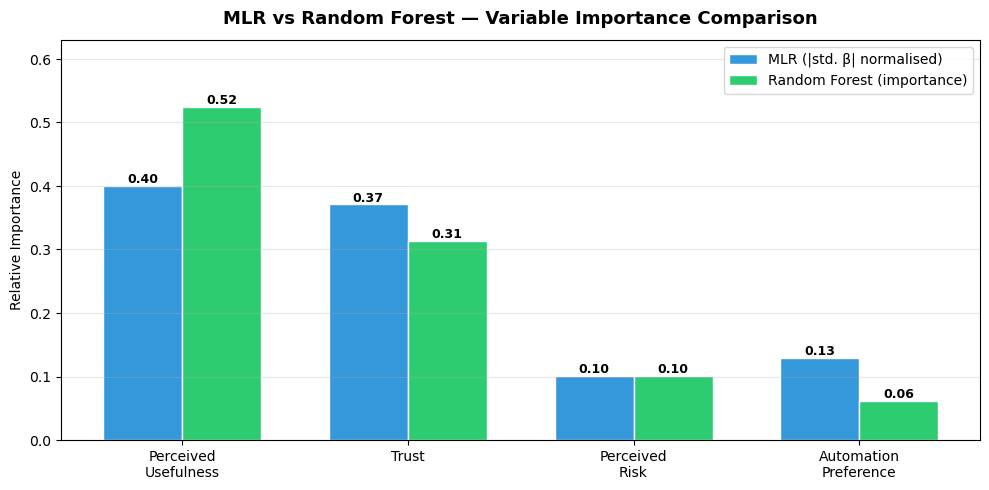

In [99]:
fig, ax = plt.subplots(figsize=(10, 5))

# MLR standardised betas (absolute values, normalised to sum to 1)
mlr_abs   = [abs(mlr_results[v]) for v in predictors]
mlr_norm  = [v / sum(mlr_abs) for v in mlr_abs]
rf_imp    = [rf_model.feature_importances_[i] for i in range(len(predictors))]

labels_comp = ['Perceived\nUsefulness', 'Trust', 'Perceived\nRisk', 'Automation\nPreference']
x_comp = np.arange(len(predictors))
w = 0.35

ax.bar(x_comp - w/2, mlr_norm, w,
       label='MLR (|std. β| normalised)', color='#3498db', edgecolor='white')
ax.bar(x_comp + w/2, rf_imp, w,
       label='Random Forest (importance)', color='#2ecc71', edgecolor='white')

for i, (m, r) in enumerate(zip(mlr_norm, rf_imp)):
    ax.text(i - w/2, m + 0.005, f'{m:.2f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, r + 0.005, f'{r:.2f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x_comp)
ax.set_xticklabels(labels_comp, fontsize=10)
ax.set_ylabel('Relative Importance', fontsize=10)
ax.set_title('MLR vs Random Forest — Variable Importance Comparison', fontsize=13, fontweight='bold', y=1.02)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(max(mlr_norm), max(rf_imp)) * 1.2)

plt.tight_layout()
plt.savefig('figure5_mlr_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()

#### **4.7. VISUALISATION**

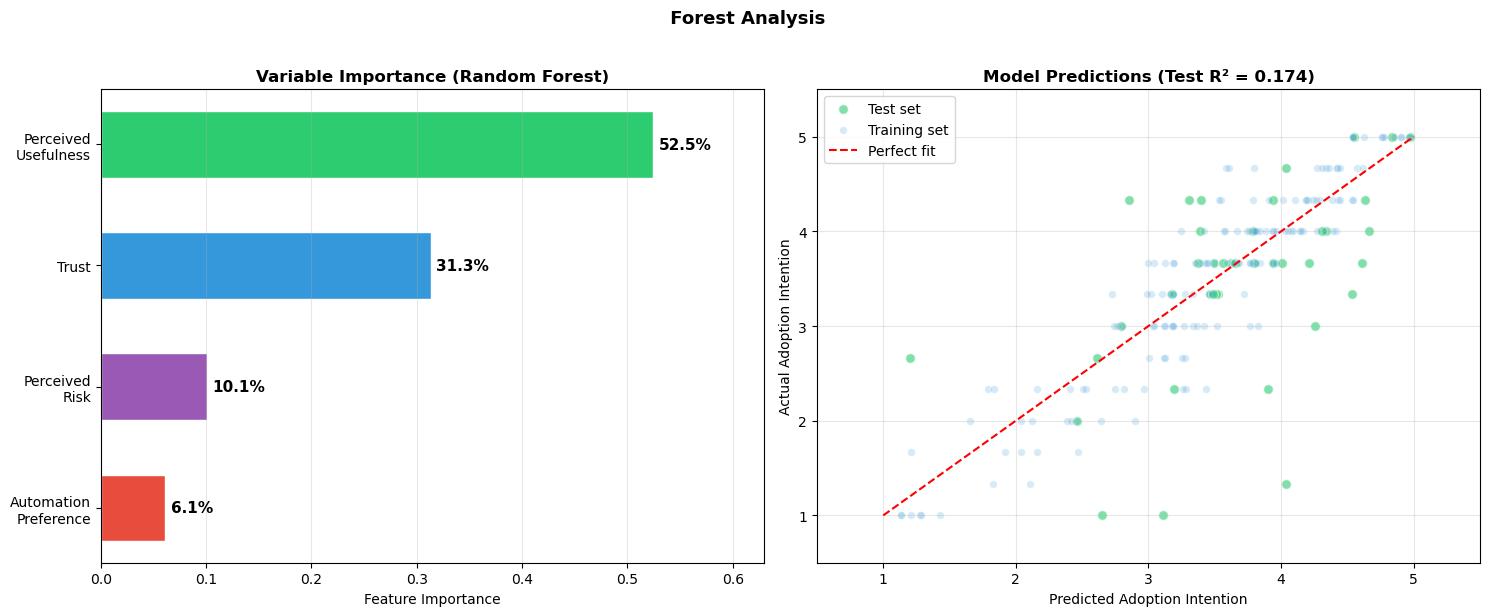

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(' Forest Analysis',
             fontsize=13, fontweight='bold', y=1.02)
 
# --- Plot 1: Feature Importance ---
ax1 = axes[0]
labels_short = {
    'PERCEIVED_USEFULNESS':  'Perceived\nUsefulness',
    'TRUST':                 'Trust',
    'PERCEIVED_RISK':        'Perceived\nRisk',
    'AUTOMATION_PREFERENCE': 'Automation\nPreference'
}
 
sorted_df = importance_df.copy()
sorted_df['Label'] = sorted_df['Variable'].map(labels_short)
 
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
 
bars = ax1.barh(sorted_df['Label'], sorted_df['Importance'],
                color=colors[:len(sorted_df)], edgecolor='white', height=0.55)
 
for bar, val in zip(bars, sorted_df['Importance']):
    ax1.text(
        val + 0.005,
        bar.get_y() + bar.get_height()/2,
        f'{val*100:.1f}%',
        va='center', ha='left',
        fontsize=11, fontweight='bold'
    )
 
ax1.set_xlabel('Feature Importance', fontsize=10)
ax1.set_title('Variable Importance (Random Forest)',
              fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()
ax1.set_xlim(0, max(sorted_df['Importance']) * 1.2)
 
# --- Plot 2: Predicted vs Actual ---
ax2 = axes[1]
ax2.scatter(y_test_pred, y_test, alpha=0.6, s=50,
            color='#2ecc71', edgecolor='white', label='Test set')
ax2.scatter(y_train_pred, y_train, alpha=0.2, s=30,
            color='#3498db', edgecolor='white', label='Training set')
 
mn, mx = 1, 5
ax2.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
 
ax2.set_xlabel('Predicted Adoption Intention', fontsize=10)
ax2.set_ylabel('Actual Adoption Intention',   fontsize=10)
ax2.set_title(f'Model Predictions (Test R² = {test_r2:.3f})',
              fontsize=12, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)
ax2.set_xlim(0.5, 5.5)
ax2.set_ylim(0.5, 5.5)
 
plt.tight_layout()

plt.show()
 

#### **4.8 SUMMARY**

In [81]:
print("=" * 75)
print("  SUMMARY — RANDOM FOREST FINDINGS")
print("=" * 75)
print()
print(f"  - Top predictor      : {importance_df.iloc[0]['Variable']} ({importance_df.iloc[0]['Importance (%)']})")
print(f"  - Second predictor   : {importance_df.iloc[1]['Variable']} ({importance_df.iloc[1]['Importance (%)']})")
print(f"  - Test R²            : {test_r2:.3f} ({test_r2*100:.1f}% variance explained)")
print(f"  - Cross-validated R² : {cv_scores.mean():.3f} (5-fold CV)")
print()
print("  This complements the MLR results, providing additional confidence")
print("  in the identification of the main drivers of adoption.")
print()
print("=" * 75)
print("  END OF STEP 4 ")
print("=" * 75)

  SUMMARY — RANDOM FOREST FINDINGS

  - Top predictor      : PERCEIVED_USEFULNESS (52.5%)
  - Second predictor   : TRUST (31.3%)
  - Test R²            : 0.174 (17.4% variance explained)
  - Cross-validated R² : 0.489 (5-fold CV)

  This complements the MLR results, providing additional confidence
  in the identification of the main drivers of adoption.

  END OF STEP 4 


### ***STEP 5: K-MEANS CLUSTERING — USER SEGMENTATION***

#### PURPOSE:
K-means clustering is an unsupervised machine learning technique thatgroups respondents into segments based on similar response patterns. This complements the previous analyses (which focused on relationships
between variables) by identifying distinct user profiles.

#### OUTCOME:
We expect to find different segments of consumers based on their attitudes towards AI shopping agents (e.g., early adopters, sceptics,
intermediates). This has direct business intelligence applications for companies designing AI-driven shopping experiences.

#### METHODOLOGY:
   1. Standardise variables (so all are on the same scale)
   2. Use the Elbow Method and Silhouette Score to choose optimal K
   3. Run K-means with the chosen K
   4. Profile each cluster and interpret the segments

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


#### **5.1 PREPARE VARIABLES FOR CLUSTERING**

We use the 5 main composite variables to cluster respondents. Standardisation is essential because K-means is sensitive to scale.
 

In [83]:
cluster_vars = [
    'PERCEIVED_USEFULNESS',
    'TRUST',
    'PERCEIVED_RISK',
    'AUTOMATION_PREFERENCE',
    'ADOPTION_INTENTION'
]
 
X = df[cluster_vars].copy()
 
# Standardise (mean = 0, std = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
print(f"  Variables used for clustering: {len(cluster_vars)}")
for v in cluster_vars:
    print(f"    - {v}")
print()

  Variables used for clustering: 5
    - PERCEIVED_USEFULNESS
    - TRUST
    - PERCEIVED_RISK
    - AUTOMATION_PREFERENCE
    - ADOPTION_INTENTION



#### **5.3 DETERMINE OPTIMAL NUMBER OF CLUSTERS**

We test K = 2 to 8 and use two methods to choose the optimal K:
- Elbow Method: looks for the "elbow" where adding more clusters  stops improving the model substantially
- Silhouette Score: measures how well-separated the clusters are (higher = better, max = 1)

In [84]:
print("-" * 75)
print("  CHOOSING OPTIMAL NUMBER OF CLUSTERS (K)")
print("-" * 75)
print()
 
k_range = range(2, 9)
inertias = []
silhouettes = []
 
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
 
result_table = pd.DataFrame({
    'K':          list(k_range),
    'Inertia':    [round(i, 2) for i in inertias],
    'Silhouette': [round(s, 4) for s in silhouettes]
})
print(result_table.to_string(index=False))
print()
 
best_k = list(k_range)[np.argmax(silhouettes)]
print(f"  >> Highest Silhouette Score at K = {best_k} ({max(silhouettes):.4f})")
print()

---------------------------------------------------------------------------
  CHOOSING OPTIMAL NUMBER OF CLUSTERS (K)
---------------------------------------------------------------------------

 K  Inertia  Silhouette
 2   686.53      0.3151
 3   545.42      0.3084
 4   458.17      0.2188
 5   408.60      0.2065
 6   369.71      0.2085
 7   334.03      0.2131
 8   313.03      0.1884

  >> Highest Silhouette Score at K = 2 (0.3151)



#### **5.4 FIT THE FINAL K-MEANS MODEL**

We choose K=3 as a balance between interpretability and Silhouette Score. Three clusters typically map well to "early adopters", "sceptics" and
"intermediates" — a common segmentation in technology adoption research.
 

In [85]:
K = 3
 
print("-" * 75)
print(f"  FINAL MODEL: K-MEANS WITH K = {K}")
print("-" * 75)
print()
 
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
 
# Cluster sizes
cluster_sizes = df['cluster'].value_counts().sort_index()
print("  Cluster sizes:")
for c, size in cluster_sizes.items():
    pct = size / len(df) * 100
    print(f"    Cluster {c}: {size:3d} respondents ({pct:.1f}%)")
print()
 

---------------------------------------------------------------------------
  FINAL MODEL: K-MEANS WITH K = 3
---------------------------------------------------------------------------

  Cluster sizes:
    Cluster 0: 124 respondents (62.0%)
    Cluster 1:  47 respondents (23.5%)
    Cluster 2:  29 respondents (14.5%)



#### **5.5 CLUSTER PROFILES**

We compute the mean of each variable within each cluster. This tells us what makes each cluster unique.

In [86]:
print("-" * 75)
print("  CLUSTER PROFILES — Mean values per cluster (1-5 scale)")
print("-" * 75)
print()
 
profile = df.groupby('cluster')[cluster_vars].mean().round(3)
profile['N'] = cluster_sizes.values
profile = profile[['N'] + cluster_vars]
print(profile.to_string())
print()

---------------------------------------------------------------------------
  CLUSTER PROFILES — Mean values per cluster (1-5 scale)
---------------------------------------------------------------------------

           N  PERCEIVED_USEFULNESS  TRUST  PERCEIVED_RISK  AUTOMATION_PREFERENCE  ADOPTION_INTENTION
cluster                                                                                             
0        124                 4.056  3.607           3.821                  1.457               4.019
1         47                 2.560  2.080           4.287                  1.376               2.262
2         29                 3.034  3.052           2.655                  3.103               3.092



#### **5.6 NAME AND INTERPRET CLUSTERS**

Clusters are labelled based on their dominant characteristics. Sort clusters by Adoption Intention to assign meaningful names.

In [87]:
profile_sorted = profile.sort_values('ADOPTION_INTENTION', ascending=False)
cluster_order = profile_sorted.index.tolist()
 
cluster_names = {
    cluster_order[0]: 'Enthusiasts',     # Highest adoption intention
    cluster_order[1]: 'Pragmatists',     # Intermediate
    cluster_order[2]: 'Sceptics'         # Lowest adoption intention
}
 
df['cluster_name'] = df['cluster'].map(cluster_names)
 
print("-" * 75)
print("  CLUSTER INTERPRETATION")
print("-" * 75)
print()
 
for c in sorted(df['cluster'].unique()):
    name = cluster_names[c]
    n = (df['cluster'] == c).sum()
    pct = n / len(df) * 100
    means = df[df['cluster'] == c][cluster_vars].mean()
 
    print(f"  CLUSTER {c} — '{name}'  ({n} respondents, {pct:.1f}%)")
    print(f"    Perceived Usefulness   : {means['PERCEIVED_USEFULNESS']:.2f}")
    print(f"    Trust                  : {means['TRUST']:.2f}")
    print(f"    Perceived Risk         : {means['PERCEIVED_RISK']:.2f}")
    print(f"    Automation Preference  : {means['AUTOMATION_PREFERENCE']:.2f}")
    print(f"    Adoption Intention     : {means['ADOPTION_INTENTION']:.2f}")
    print()
 
 

---------------------------------------------------------------------------
  CLUSTER INTERPRETATION
---------------------------------------------------------------------------

  CLUSTER 0 — 'Enthusiasts'  (124 respondents, 62.0%)
    Perceived Usefulness   : 4.06
    Trust                  : 3.61
    Perceived Risk         : 3.82
    Automation Preference  : 1.46
    Adoption Intention     : 4.02

  CLUSTER 1 — 'Sceptics'  (47 respondents, 23.5%)
    Perceived Usefulness   : 2.56
    Trust                  : 2.08
    Perceived Risk         : 4.29
    Automation Preference  : 1.38
    Adoption Intention     : 2.26

  CLUSTER 2 — 'Pragmatists'  (29 respondents, 14.5%)
    Perceived Usefulness   : 3.03
    Trust                  : 3.05
    Perceived Risk         : 2.66
    Automation Preference  : 3.10
    Adoption Intention     : 3.09



#### **5.7 DEMOGRAPHIC PROFILE OF EACH CLUSTER**

In [88]:
print("-" * 75)
print("  DEMOGRAPHIC PROFILE OF EACH CLUSTER")
print("-" * 75)
print()
 
demo_vars = ['age', 'gender', 'ai_familiarity', 'ai_prior_use', 'tech_comfort']
demo_profile = df.groupby('cluster_name')[demo_vars].mean().round(2)
print(demo_profile.to_string())
print()

---------------------------------------------------------------------------
  DEMOGRAPHIC PROFILE OF EACH CLUSTER
---------------------------------------------------------------------------

               age  gender  ai_familiarity  ai_prior_use  tech_comfort
cluster_name                                                          
Enthusiasts   1.77    1.49            3.88          3.35          4.00
Pragmatists   1.97    1.48            3.45          2.79          3.69
Sceptics      2.06    1.38            3.30          2.13          3.68



#### **5.8  VISUALISATION**

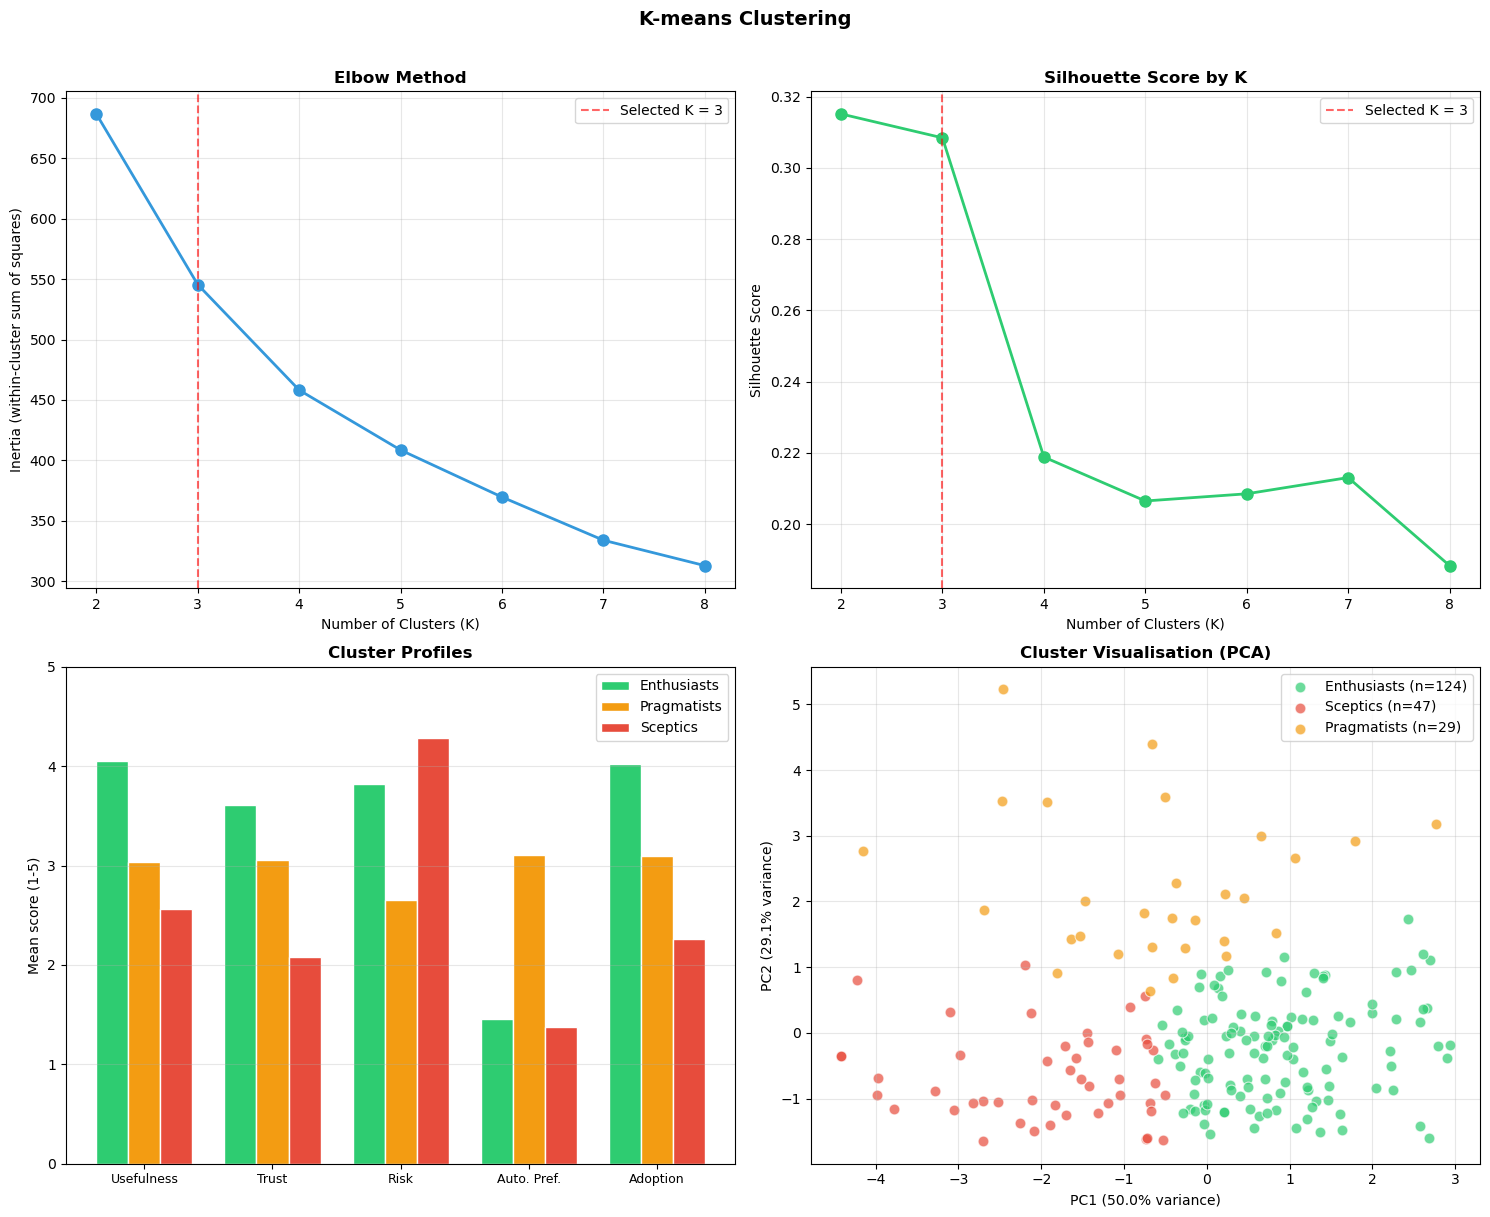

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('K-means Clustering',
             fontsize=14, fontweight='bold', y=1.01)
 
# --- Plot 1: Elbow Method ---
ax1 = axes[0, 0]
ax1.plot(list(k_range), inertias, 'o-', linewidth=2, markersize=8, color='#3498db')
ax1.axvline(x=K, color='red', linestyle='--', alpha=0.6, label=f'Selected K = {K}')
ax1.set_xlabel('Number of Clusters (K)', fontsize=10)
ax1.set_ylabel('Inertia (within-cluster sum of squares)', fontsize=10)
ax1.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend()
 
# --- Plot 2: Silhouette Score ---
ax2 = axes[0, 1]
ax2.plot(list(k_range), silhouettes, 'o-', linewidth=2, markersize=8, color='#2ecc71')
ax2.axvline(x=K, color='red', linestyle='--', alpha=0.6, label=f'Selected K = {K}')
ax2.set_xlabel('Number of Clusters (K)', fontsize=10)
ax2.set_ylabel('Silhouette Score', fontsize=10)
ax2.set_title('Silhouette Score by K', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend()
 
# --- Plot 3: Cluster profiles (radar-like bar chart) ---
ax3 = axes[1, 0]
labels_short = ['Usefulness', 'Trust', 'Risk', 'Auto. Pref.', 'Adoption']
cluster_colors = {'Enthusiasts': '#2ecc71', 'Pragmatists': '#f39c12', 'Sceptics': '#e74c3c'}
 
x = np.arange(len(labels_short))
width = 0.25
 
for i, name in enumerate(['Enthusiasts', 'Pragmatists', 'Sceptics']):
    cluster_id = [k for k, v in cluster_names.items() if v == name][0]
    values = profile.loc[cluster_id, cluster_vars].values
    offset = (i - 1) * width
    ax3.bar(x + offset, values, width, label=name,
            color=cluster_colors[name], edgecolor='white')
 
ax3.set_xticks(x)
ax3.set_xticklabels(labels_short, fontsize=9)
ax3.set_ylabel('Mean score (1-5)', fontsize=10)
ax3.set_title('Cluster Profiles', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 5)
ax3.legend(loc='upper right')
ax3.grid(axis='y', alpha=0.3)
 
# --- Plot 4: 2D scatter using PCA ---
ax4 = axes[1, 1]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
 
for cluster_id in sorted(df['cluster'].unique()):
    name = cluster_names[cluster_id]
    mask = df['cluster'] == cluster_id
    ax4.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=60, alpha=0.7,
                color=cluster_colors[name],
                edgecolor='white', linewidth=0.8,
                label=f'{name} (n={mask.sum()})')
 
ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
ax4.set_title('Cluster Visualisation (PCA)', fontsize=12, fontweight='bold')
ax4.legend(loc='best')
ax4.grid(alpha=0.3)
 
plt.tight_layout()

plt.show()

#### **5.9 SUMMARY & BUSINESS IMPLICATIONS**

In [94]:
print("=" * 75)
print("  SUMMARY — KEY FINDINGS")
print("=" * 75)
print()
 
for c in sorted(df['cluster'].unique()):
    name = cluster_names[c]
    n = (df['cluster'] == c).sum()
    pct = n / len(df) * 100
    ai = df[df['cluster'] == c]['ADOPTION_INTENTION'].mean()
    print(f"  - {name}: {pct:.0f}% of sample (mean Adoption Intention = {ai:.2f})")
 
print()
print("  Three distinct user profiles emerged from the data, providing a")
print("  valuable basis for targeted marketing and product strategies.")
print()
print("=" * 75)
print("  END OF STEP 5")
print("=" * 75)

  SUMMARY — KEY FINDINGS

  - Enthusiasts: 62% of sample (mean Adoption Intention = 4.02)
  - Sceptics: 24% of sample (mean Adoption Intention = 2.26)
  - Pragmatists: 14% of sample (mean Adoption Intention = 3.09)

  Three distinct user profiles emerged from the data, providing a
  valuable basis for targeted marketing and product strategies.

  END OF STEP 5
